In [2]:
### Lecture 6 in-class lecture
# start by loading the library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# create the new data link
df = pd.read_csv("data/unrate_data.csv")
df.head()

,date,unrate,unrate_nsa,u_texas,u_alaska,u_california,u_new_york,u_florida,u_montana,u_iowa
0,1976-01-01,7.9,8.8,5.8,7.1,9.2,10.3,9.6,5.9,4.4
1,1976-02-01,7.7,8.7,5.8,7.1,9.2,10.3,9.7,5.9,4.4
2,1976-03-01,7.6,8.1,5.9,7.0,9.1,10.2,9.6,5.9,4.4
3,1976-04-01,7.7,7.4,5.9,7.0,9.0,10.2,9.5,5.9,4.3
4,1976-05-01,7.4,6.8,6.0,7.0,8.9,10.2,9.3,5.9,4.2


In [4]:
# handling the missing value
df.isna().sum()

date            0
unrate          1
unrate_nsa      1
u_texas         1
u_alaska        1
u_california    1
u_new_york      1
u_florida       1
u_montana       1
u_iowa          1
dtype: int64

In [ ]:
# improvement of the filter
#mask = df.isna().any(axis=1)        
# one True/False per row
#missing_rows = df[mask]             
# keep only rows with any missing values
#missing_rows

missing_rows = df.isna().any(axis =1)
# axis = 1 tell to look horizontally and return true if one na in the line (.all(...) tell to return true if they are all na)
df[missing_rows]
# in october 2025 there was the federal shutdown so normal not to have any value


,date,unrate,unrate_nsa,u_texas,u_alaska,u_california,u_new_york,u_florida,u_montana,u_iowa
597,2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# View the last few rows to see the gap surrounded by valid data
df.tail()

,date,unrate,unrate_nsa,u_texas,u_alaska,u_california,u_new_york,u_florida,u_montana,u_iowa
595,2025-08-01,4.3,4.5,4.1,4.7,5.5,4.0,3.8,2.9,3.8
596,2025-09-01,4.4,4.3,4.1,4.7,5.6,4.2,3.9,3.0,3.7
597,2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
598,2025-11-01,4.5,4.3,4.2,4.7,5.6,4.5,4.2,3.3,3.5
599,2025-12-01,4.4,4.1,4.3,4.8,5.5,4.6,4.3,3.4,3.5


Economists generally use one of three approaches to deal with NaN values:

Dropping (.dropna()): This removes any row containing a missing value.
When to use: Use this when the missing data is minimal or when “guessing” a value would compromise your analysis.

Filling (.fillna(), .ffill(), .bfill()): This replaces NaN with values
When to use: Common for “sticky” variables like tax rates or policy targets that remain constant until updated.

Interpolation (.interpolate()): This estimates the missing point by “drawing a line” between the values before and after the gap.
When to use: This is the preferred method for smooth economic indicators like the unemployment rate or GDP.

You can also keep NaNs in your dataframe, as long as you are aware of it and keep it in mind when you calculate statistics or run regressions. Pandas will often ignore NaNs automatically when calculating for example a mean, but libraries like statsmodels or scikit-learn will throw an error if you feed them missing data.

In [9]:
# removing the rows with na
# usefull for regression where we need to have a complete set of variable for every observation
# Drop all rows that have at least one missing value
test_df = df.dropna()
test_df.tail()

,date,unrate,unrate_nsa,u_texas,u_alaska,u_california,u_new_york,u_florida,u_montana,u_iowa
594,2025-07-01,4.3,4.6,4.0,4.8,5.5,4.0,3.7,2.8,3.7
595,2025-08-01,4.3,4.5,4.1,4.7,5.5,4.0,3.8,2.9,3.8
596,2025-09-01,4.4,4.3,4.1,4.7,5.6,4.2,3.9,3.0,3.7
598,2025-11-01,4.5,4.3,4.2,4.7,5.6,4.5,4.2,3.3,3.5
599,2025-12-01,4.4,4.1,4.3,4.8,5.5,4.6,4.3,3.4,3.5


You can fine-tune how aggressively Pandas deletes data. using these parameters:

subset: Only looks for missing values in specific columns. For example, if you have missing data in a “Notes” column that you don’t care about, but you want to keep all rows where the “unrate” is valid, you would use this.

how: Defines the condition for dropping.
how='any' (default): Drops the row if any column has a NaN.
how='all': Only drops the row if all columns are missing.
axis: Determines whether to drop rows or columns.
axis=0 (default): Drops rows.
axis=1: Drops columns that contain missing values

In [10]:
# Drop all columns that contain missing data
test_df = df.dropna(axis=1)
test_df.head()  

,date
0,1976-01-01
1,1976-02-01
2,1976-03-01
3,1976-04-01
4,1976-05-01


In [13]:
# Create a test dataframe test_df to try different methods
test_df = df.loc[:,['date', 'u_florida']]
test_df.tail()      # show tail, that's where the missing value is in this example

,date,u_florida
595,2025-08-01,3.8
596,2025-09-01,3.9
597,2025-10-01,NaN
598,2025-11-01,4.2
599,2025-12-01,4.3


In [14]:
# 1. Forward Fill: Carry the last known unemployment rate forward
test_df['unrate_ffill'] = test_df['u_florida'].ffill()
test_df.tail()

,date,u_florida,unrate_ffill
595,2025-08-01,3.8,3.8
596,2025-09-01,3.9,3.9
597,2025-10-01,NaN,3.9
598,2025-11-01,4.2,4.2
599,2025-12-01,4.3,4.3


In [15]:
# 2. Backward Fill: Use the next known rate to fill previous gaps
test_df['unrate_bfill'] = test_df['u_florida'].bfill()
test_df.tail()

,date,u_florida,unrate_ffill,unrate_bfill
595,2025-08-01,3.8,3.8,3.8
596,2025-09-01,3.9,3.9,3.9
597,2025-10-01,NaN,3.9,4.2
598,2025-11-01,4.2,4.2,4.2
599,2025-12-01,4.3,4.3,4.3


In [16]:
# 3. Custom Fill: Replace all NaNs with a specific constant
# Useful if you want to treat missing values as a specific baseline
test_df['unrate_fixed'] = test_df['u_florida'].fillna(5.0)
test_df.tail()

# .fillna(): This is the most flexible method, allowing you to replace all NaN values with a specific constant (like 0) or a calculated value (like the mean of the column).
# Warning for Economists: Filling with 0 or the mean can significantly bias your results if the variable (like unemployment) naturally fluctuates over time.

,date,u_florida,unrate_ffill,unrate_bfill,unrate_fixed
595,2025-08-01,3.8,3.8,3.8,3.8
596,2025-09-01,3.9,3.9,3.9,3.9
597,2025-10-01,NaN,3.9,4.2,5.0
598,2025-11-01,4.2,4.2,4.2,4.2
599,2025-12-01,4.3,4.3,4.3,4.3


In [17]:
# 4. Statistical Fill: Replace NaNs with the average of the column
test_df['unrate_mean'] = test_df['u_florida'].fillna(test_df['u_florida'].mean())
test_df.tail()

,date,u_florida,unrate_ffill,unrate_bfill,unrate_fixed,unrate_mean
595,2025-08-01,3.8,3.8,3.8,3.8,3.800000
596,2025-09-01,3.9,3.9,3.9,3.9,3.900000
597,2025-10-01,NaN,3.9,4.2,5.0,5.970618
598,2025-11-01,4.2,4.2,4.2,4.2,4.200000
599,2025-12-01,4.3,4.3,4.3,4.3,4.300000


.interpolate() estimates missing values by looking at the surrounding observations and “filling in the gaps” based on a mathematical trend. Pandas allows you to choose the “shape” of the line used to fill the gap via the method argument:

method='linear' (Default): Treats the distance between points as a straight line. This is the most common choice for smooth economic trends like unemployment or GDP.

method='time': Similar to linear, but it accounts for the actual time between observations. This is crucial if your dates are not evenly spaced (e.g., jumping from a Monday to a Friday).

method='polynomial' or 'spline': These create curved lines. Use these only if you have a strong theoretical reason to believe the data follows a complex curve rather than a steady trend.

In [18]:
# Linear interpolation 
test_df['unrate_interp'] = test_df['u_florida'].interpolate(method='linear')
test_df.tail()

,date,u_florida,unrate_ffill,unrate_bfill,unrate_fixed,unrate_mean,unrate_interp
595,2025-08-01,3.8,3.8,3.8,3.8,3.800000,3.80
596,2025-09-01,3.9,3.9,3.9,3.9,3.900000,3.90
597,2025-10-01,NaN,3.9,4.2,5.0,5.970618,4.05
598,2025-11-01,4.2,4.2,4.2,4.2,4.200000,4.20
599,2025-12-01,4.3,4.3,4.3,4.3,4.300000,4.30


In [20]:
# Analysing the datatype of the data
print(df["date"].dtype)
# The column ‘date’ is a string. This is typical when you read data from a .csv file.
# If dates are strings, pandas will not automatically understand things like:
# sorting dates correctly, filtering by time ranges, resampling (e.g. monthly to yearly), extracting year/month/quarter, plotting time series on a proper time axis

str


In [21]:
# Once a column is converted to datetime, pandas understands it as time data and gives you powerful time-series tools.
# 1. Convert the column to datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Check the info again to see the 'datetime64[us]' type
print(df['date'].dtype)

datetime64[us]


pd.to_datetime() will often recognize the format automatically. But if the format is unusual or ambiguous, you may need to tell pandas exactly how the date is written using the format= argument.

For example

"2020-03-01" corresponds to "%Y-%m-%d"
"03/01/2020" corresponds to "%m/%d/%Y"
"01/03/2020" corresponds to "%d/%m/%Y"
"2020|03|01" corresponds to "%Y|%m|%d"
Common format codes:

%Y = 4-digit year (2020)
%m = month (01–12)
%d = day (01–31)

In [22]:
# Create a dataframe with a bad date format for illustration
df_bad_format = pd.DataFrame({"date_str": ["2020|03|01", "2020|04|01", "2020|05|01"]})

df_bad_format

,date_str
0,2020|03|01
1,2020|04|01
2,2020|05|01


In [26]:
# because the formating is wrong is send an error
# df_bad_format["date"] = pd.to_datetime(df_bad_format["date_str"])

In [27]:
df_bad_format["date"] = pd.to_datetime(df_bad_format["date_str"], format="%Y|%m|%d")
df_bad_format

,date_str,date
0,2020|03|01,2020-03-01
1,2020|04|01,2020-04-01
2,2020|05|01,2020-05-01


Once a column is in datetime64 format, you can use the .dt accessor to extract specific parts of the date. This is incredibly useful for comparing seasonal trends (e.g., comparing every January) or grouping data by year.

df['date'].dt.year: Extracts the year (2024, 2025, etc.)
df['date'].dt.month: Extracts the month as a number (1-12)
df['date'].dt.day: Extracts the day of the month
df['date'].dt.quarter: Extracts the fiscal quarter (1-4)
df['date'].dt.weekday: 0 for Monday, 6 for Sunday
.dt.month_name(): month name (January, February, …)

In [29]:
# Example: Extract year and month
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()

# Note: The .dt accessor is used for standard columns. 
# Later, if we set the date as our DataFrame's Index, we would use: df.index.year

df[["date", "year", "month", "month_name"]].head()

,date,year,month,month_name
0,1976-01-01,1976,1,January
1,1976-02-01,1976,2,February
2,1976-03-01,1976,3,March
3,1976-04-01,1976,4,April
4,1976-05-01,1976,5,May


In [30]:
# Calculate the average unemployment rate for each month
monthly_avg = df.groupby('month')['unrate_nsa'].mean()
monthly_avg = monthly_avg.reset_index()
monthly_avg

,month,unrate_nsa
0,1,6.616000
1,2,6.508000
2,3,6.264000
3,4,5.970000
4,5,5.920000
5,6,6.350000
6,7,6.298000
7,8,6.046000
8,9,5.814000
9,10,5.706122


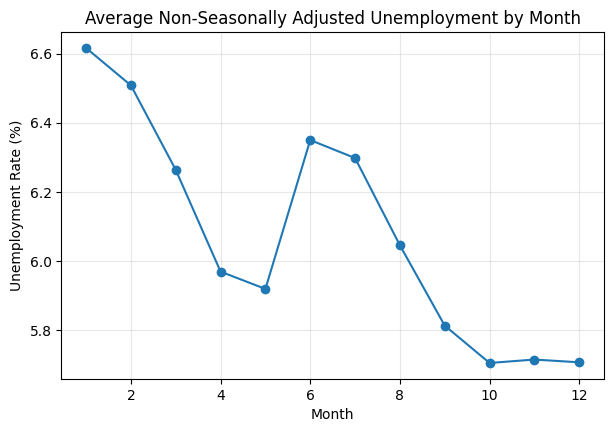

In [31]:
plt.figure(figsize=(7,4.5))
# Plot the data (x = the month index, y = the average rates)
plt.plot(monthly_avg['month'], monthly_avg['unrate_nsa'], marker='o')

# Add some basic labels
plt.title("Average Non-Seasonally Adjusted Unemployment by Month")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.grid(alpha = 0.3)
# Display the plot
plt.show()

In [32]:
# For time series, it is very common to use the date column as the index (.set_index()). When setting the index, it is best practice to sort immediately (.sort_index()).
# Set the date as the index AND sort it chronologically
df = df.set_index('date').sort_index()

# Preview the first few rows
df.head() 

,unrate,unrate_nsa,u_texas,u_alaska,u_california,u_new_york,u_florida,u_montana,u_iowa,year,month,month_name
date,,,,,,,,,,,,
1976-01-01,7.9,8.8,5.8,7.1,9.2,10.3,9.6,5.9,4.4,1976,1,January
1976-02-01,7.7,8.7,5.8,7.1,9.2,10.3,9.7,5.9,4.4,1976,2,February
1976-03-01,7.6,8.1,5.9,7.0,9.1,10.2,9.6,5.9,4.4,1976,3,March
1976-04-01,7.7,7.4,5.9,7.0,9.0,10.2,9.5,5.9,4.3,1976,4,April
1976-05-01,7.4,6.8,6.0,7.0,8.9,10.2,9.3,5.9,4.2,1976,5,May


When the index contains datetime values, pandas uses a special type called a DateTimeIndex.

A DateTimeIndex makes time-series work much easier. It allows pandas to understand that your rows are ordered in time, which helps with:

time-based filtering (e.g. all observations in 2020)
resampling (monthly → yearly averages)
rolling windows (moving averages)
plotting with a proper time axis

In [33]:
print(type(df.index))

<class 'pandas.DatetimeIndex'>


In [34]:
# Select everything from 2015 to the end of 2019
pre_pandemic = df.loc["2015":"2019"]
pre_pandemic.head()

,unrate,unrate_nsa,u_texas,u_alaska,u_california,u_new_york,u_florida,u_montana,u_iowa,year,month,month_name
date,,,,,,,,,,,,
2015-01-01,5.7,6.1,4.5,6.3,6.8,5.7,5.9,4.3,3.9,2015,1,January
2015-02-01,5.5,5.8,4.5,6.3,6.7,5.6,5.8,4.3,3.8,2015,2,February
2015-03-01,5.4,5.6,4.5,6.3,6.6,5.6,5.8,4.2,3.8,2015,3,March
2015-04-01,5.4,5.1,4.4,6.3,6.5,5.5,5.7,4.2,3.8,2015,4,April
2015-05-01,5.6,5.3,4.4,6.3,6.4,5.4,5.6,4.2,3.7,2015,5,May


In [35]:
# Select a specific window (e.g., the Great Recession)
great_recession = df.loc["December 2007":"2009-06"]
great_recession.head()

,unrate,unrate_nsa,u_texas,u_alaska,u_california,u_new_york,u_florida,u_montana,u_iowa,year,month,month_name
date,,,,,,,,,,,,
2007-12-01,5.0,4.8,4.3,6.2,5.8,4.7,4.7,3.8,3.7,2007,12,December
2008-01-01,5.0,5.4,4.3,6.2,5.9,4.7,4.8,3.8,3.6,2008,1,January
2008-02-01,4.9,5.2,4.3,6.2,6.0,4.7,5.0,3.9,3.6,2008,2,February
2008-03-01,5.1,5.2,4.3,6.3,6.2,4.8,5.2,4.0,3.7,2008,3,March
2008-04-01,5.0,4.8,4.4,6.3,6.4,4.9,5.5,4.1,3.8,2008,4,April


In [36]:
# Check the frequency of our unemployment data
print(df.index.freq)

None


If this returns None, it means Pandas hasn’t automatically inferred the frequency yet. You can set it manually using .asfreq().

Pandas uses short codes (aliases) to represent different time intervals. Here are the ones you will encounter most often in economic research:

'D': Calendar day
'B': Business day
'MS': Month Start
'ME': Month End
'QS': Quarter Start
'QE': Quarter End
'YS': Year Start
If your data is monthly but the frequency is not set, you can “enforce” it.

In [37]:
df = df.asfreq('MS')
print(df.index.freq)

<MonthBegin>


In [38]:
test = df.copy()
test = test.asfreq('D')
test.head()

,unrate,unrate_nsa,u_texas,u_alaska,u_california,u_new_york,u_florida,u_montana,u_iowa,year,month,month_name
date,,,,,,,,,,,,
1976-01-01,7.9,8.8,5.8,7.1,9.2,10.3,9.6,5.9,4.4,1976.0,1.0,January
1976-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In economic research, you often need to combine datasets that are released at different intervals. For example, you might have monthly unemployment data but quarterly GDP data. Resampling is the process of changing the frequency of your time series observations.

Basic Syntax: df['column_name'].resample().aggregation_method()

Resampling only works properly if:

the index is a DateTimeIndex
the index is sorted

In [39]:
# Before you resample:
# Check that the index is correct:
print(type(df.index))

# Sort the index
df = df.sort_index()

<class 'pandas.DatetimeIndex'>


Downsampling (High Frequency to Low Frequency)

Downsampling is when you reduce the frequency of your data (e.g., moving from Monthly to Yearly). Because you are condensing multiple data points into one, you must decide how to represent that period (the “aggregation method”).

Common aggregation methods:

.mean(): The average value over the period (standard for unemployment).

.sum(): The total value (standard for flows like “Total Exports”).

.last(): The value at the end of the period (often used for stock prices or debt levels).

In [40]:
# Resample from Monthly (MS) to Year Start (YS)
# We take the mean to get the average unemployment rate for each year
annual_unrate = df['unrate'].resample('YS').mean()
annual_unrate.head()

date
1976-01-01    7.700000
1977-01-01    7.050000
1978-01-01    6.066667
1979-01-01    5.850000
1980-01-01    7.175000
Freq: YS-JAN, Name: unrate, dtype: float64

In [ ]:
# Because we’re resampling one column it will return a pandas Series and not a DataFrame (that’s why the output looks the way it does). If you want a DataFrame instead just add .to_frame() in the end or select the colum with double brackets [['unrate']].

# Option 1: Resample from Monthly (MS) to Year Start (YS) and make it a dataframe
annual_unrate = df['unrate'].resample('YS').mean().to_frame()

annual_unrate.head()

,unrate
date,
1976-01-01,7.700000
1977-01-01,7.050000
1978-01-01,6.066667
1979-01-01,5.850000
1980-01-01,7.175000


In [42]:
# Option 2: Resample from Monthly (MS) to Year Start (YS) and make it a dataframe
annual_unrate = df[['unrate']].resample('YS').mean()

annual_unrate.head()

,unrate
date,
1976-01-01,7.700000
1977-01-01,7.050000
1978-01-01,6.066667
1979-01-01,5.850000
1980-01-01,7.175000


Think of a DataFrame as an entire spreadsheet, and a Series as a single column within that spreadsheet. Mechanically, a DataFrame is a two-dimensional table made up of multiple one-dimensional Series that all share the same index (the row labels). This is why extracting a single column from your data (e.g., df['unrate']) returns a Series, while extracting multiple columns returns a DataFrame.

In [43]:
annual_df = df.drop(columns=['month_name']).resample('YS').mean()
annual_df.head()

,unrate,unrate_nsa,u_texas,u_alaska,u_california,u_new_york,u_florida,u_montana,u_iowa,year,month
date,,,,,,,,,,,
1976-01-01,7.700000,7.716667,5.841667,7.591667,9.158333,10.208333,9.250000,5.933333,4.141667,1976.0,6.5
1977-01-01,7.050000,7.066667,5.433333,9.825000,8.383333,9.150000,8.266667,6.191667,4.050000,1977.0,6.5
1978-01-01,6.066667,6.066667,4.866667,10.608333,7.150000,7.708333,6.791667,5.600000,3.866667,1978.0,6.5
1979-01-01,5.850000,5.833333,4.408333,9.050000,6.216667,7.091667,5.975000,5.216667,4.191667,1979.0,6.5
1980-01-01,7.175000,7.141667,5.250000,9.541667,6.908333,7.425000,5.983333,6.325000,5.991667,1980.0,6.5


It works, but clearly for the variables year, quarter and month that we created previously it doesn’t really make sense. Note that here you don’t need to_frame() because resampling more than one column or the entire dataframe will return a DataFrame already.

Upsampling (Low Frequency to High Frequency)

Upsampling is when you increase the frequency (e.g., moving from Quarterly to Monthly). This creates “empty” rows because Pandas doesn’t know what happened between the original data points.

To fill these new rows, we use the same techniques we learned for handling missing data:

.ffill(): Carry the last known value forward.
.interpolate(): Estimate the values between points (creates a smoother line).

In [44]:
monthly_estimate = annual_unrate.resample('MS').interpolate(method='linear')
monthly_estimate.head(15)

,unrate
date,
1976-01-01,7.700000
1976-02-01,7.645833
1976-03-01,7.591667
1976-04-01,7.537500
1976-05-01,7.483333
1976-06-01,7.429167
1976-07-01,7.375000
1976-08-01,7.320833
1976-09-01,7.266667


Mechanically, this interpolation works perfectly. However, always think about the economic reality of your data! We took an annual average and placed it on January 1st, then drew a straight line to the next January 1st. In reality, the annual average represents the whole year, not just January. Be very careful when upsampling low-frequency data. You must be just as careful here as you are with missing data. Inappropriate filling or interpolation can introduce severe biases, artificial smoothness (which destroys volatility metrics), or false trends into your regressions. Always think about the economic reality of the variable before you synthesize data to fill the gaps!

Shifting Data (Lags and Leads)
The .shift() method allows you to move data up or down along the index. This is essential for creating “lags”—using past values to explain current outcomes.

Lag (Positive shift): df.shift(1) moves data “down,” so the value for January now appears next to the February index. This is how you represent “last month’s value.”
Lead (Negative shift): df.shift(-1) moves data “up,” representing “next month’s value.”
.shift() moves the values relative to the index; it does not change the dates themselves.

In [ ]:
# Create a lag: 'unrate_prev' will show the previous month's value
df['unrate_prev'] = df['unrate'].shift(1)

# Create a lead: 'unrate_next' will show the next month's value
df['unrate_next'] = df['unrate'].shift(-1)

# Check the first few rows (in the first row unrate_prev will be NaN because there is no 'previous' value for it)
df[['unrate', 'unrate_prev', 'unrate_next']].head()

,unrate,unrate_prev,unrate_next
date,,,
1976-01-01,7.9,NaN,7.7
1976-02-01,7.7,7.9,7.6
1976-03-01,7.6,7.7,7.7
1976-04-01,7.7,7.6,7.4
1976-05-01,7.4,7.7,7.6


Calculating Differences

Once you have a lagged value, you can calculate the change in the unemployment rate, the difference between the unemployment rate in one month and the unemployment rate in the previous month.

There’s a simpler way that does exactly the same: .diff().

In [ ]:
# Calculate difference using the lagged unemployment rate:
df['unrate_diff'] = df['unrate'] - df['unrate'].shift(1)

# Or use the built-in pandas method:
df['unrate_diff_alt'] = df['unrate'].diff()


df[['unrate_diff', 'unrate_diff_alt']].head()

# If you want to create the difference between the current value and the a year (12 months) ago, you can use .diff(12)

,unrate_diff,unrate_diff_alt
date,,
1976-01-01,NaN,NaN
1976-02-01,-0.2,-0.2
1976-03-01,-0.1,-0.1
1976-04-01,0.1,0.1
1976-05-01,-0.3,-0.3


Percent Change (Growth Rates)

For many economic variables (like GDP or CPI), we care about the growth rate. The .pct_change() method automates this calculation.

Month-over-Month (MoM): df['unrate'].pct_change(1)
Year-over-Year (YoY): df['unrate'].pct_change(12) (since our data is monthly, a 12-period shift looks back exactly one year).

In [47]:
df['unrate_mom_pct'] = df['unrate'].pct_change(1) * 100

df['unrate_yoy_pct'] = df['unrate'].pct_change(12) * 100

df[['unrate', 'unrate_mom_pct', 'unrate_yoy_pct']].head(20)

,unrate,unrate_mom_pct,unrate_yoy_pct
date,,,
1976-01-01,7.9,NaN,NaN
1976-02-01,7.7,-2.531646,NaN
1976-03-01,7.6,-1.298701,NaN
1976-04-01,7.7,1.315789,NaN
1976-05-01,7.4,-3.896104,NaN
1976-06-01,7.6,2.702703,NaN
1976-07-01,7.8,2.631579,NaN
1976-08-01,7.8,0.000000,NaN
1976-09-01,7.6,-2.564103,NaN


Be careful when applying .pct_change() to variables that are already percentages, like the unemployment rate! If unemployment goes from 4.0% to 5.0%, economists say it rose by “1 percentage point” (which you calculate using .diff()). Using .pct_change() will tell you it grew by 25%. We usually use .pct_change() for levels like GDP or population!

Log-Differences

To calculate logarithms, we need a new library: NumPy (Numerical Python). NumPy is the foundational math and array library in Python- We will use NumPy’s np.log() function.

Example: Create a new variable unrate_log_diff as the log difference of the unemployment rate unrate by taking the logarithm first and then the first difference:

In [48]:
# 1. Take the natural log of the column
# 2. Chain the .diff() method to calculate the period-to-period change
df['unrate_log_diff'] = np.log(df['unrate']).diff()

# Compare the standard percent change to the log difference
# Notice how similar the values are for small changes!
df[['unrate', 'unrate_mom_pct', 'unrate_log_diff']].head()

,unrate,unrate_mom_pct,unrate_log_diff
date,,,
1976-01-01,7.9,NaN,NaN
1976-02-01,7.7,-2.531646,-0.025642
1976-03-01,7.6,-1.298701,-0.013072
1976-04-01,7.7,1.315789,0.013072
1976-05-01,7.4,-3.896104,-0.039740


Rolling Windows
Economic data—especially monthly indicators like the unemployment rate—can be “noisy.” A single bad month might be an outlier rather than a change in the economic trend. To see the underlying signal, economists use Rolling Windows (also known as Moving Averages).

A rolling window “slides” over your data. For each date, a rolling window looks at the current observation and a fixed number of previous observations, and calculates a statistic (like the mean).

The .rolling() Syntax

To create a rolling window, we use the .rolling() method followed by an aggregation function like .mean().

window: The number of observations to include in each calculation. For monthly data, a window=12 gives you a 1-year moving average. (Current month + previous 11 months)
center: (Optional) If True, the average is assigned to the middle of the window rather than the end.

In [49]:
# Calculate a 12-month rolling average
# This smooths out seasonal "wiggles" to show the yearly trend
df['unrate_12m_avg'] = df['unrate'].rolling(window=12).mean()

# Check the head - the first 11 rows will be NaN 
# because there isn't enough data yet to fill a 12-month window.
df[['unrate', 'unrate_12m_avg']].head(15)

,unrate,unrate_12m_avg
date,,
1976-01-01,7.9,NaN
1976-02-01,7.7,NaN
1976-03-01,7.6,NaN
1976-04-01,7.7,NaN
1976-05-01,7.4,NaN
1976-06-01,7.6,NaN
1976-07-01,7.8,NaN
1976-08-01,7.8,NaN
1976-09-01,7.6,NaN


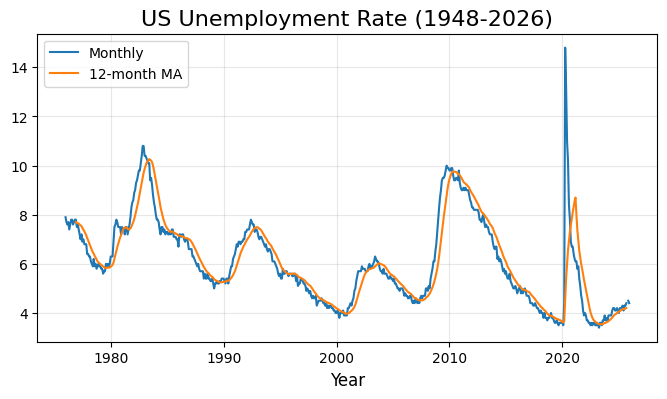

In [50]:
# Create the figure and axis
plt.figure(figsize=(8, 4))

# Plot the unemployment rate
plt.plot(df.index, df['unrate'], label = 'Monthly')
plt.plot(df.index, df['unrate_12m_avg'], label='12-month MA')

# Add essential labels
plt.title("US Unemployment Rate (1948-2026)", fontsize=16)
plt.xlabel("Year", fontsize=12)

# Add a grid for readability
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

The 12-month moving average effectively smooths out short-term fluctuations. However, this smoothness comes at a cost: moving averages are inherently lagging indicators. Because today’s 12-month average includes data from 11 months ago, it reacts very slowly to sudden economic turning points. If the economy suddenly enters a recession and unemployment spikes, the raw monthly data will show it immediately, but the moving average will take several months to fully bend upwards and reflect the new reality.

While .mean() is the most common rolling aggregation, Pandas allows you to calculate almost any statistic over a moving window. For instance, you might use .sum() for rolling totals, .max() to track rolling peaks, or .std() to measure rolling volatility (a crucial metric in finance to see how risk changes over time).

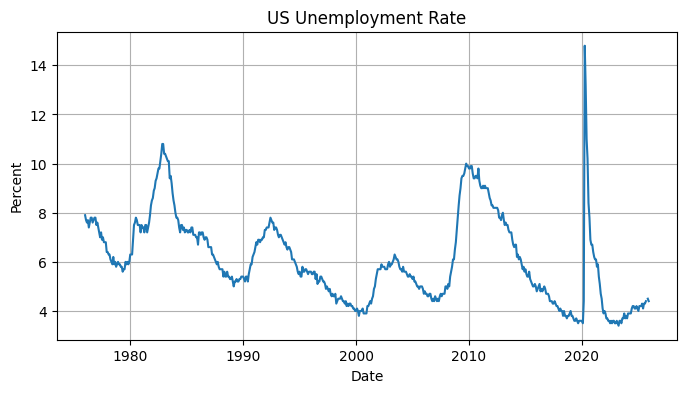

In [52]:
plt.figure(figsize=(8, 4))
plt.plot(df.index, df["unrate"])

plt.title("US Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Percent")

plt.grid()
plt.show()

Step 2: Improve the styling (colors, lines, fonts, and grid)
You can improve readability and emphasis using standard Matplotlib arguments that control colors, line styles, fonts, and grid lines.

In plt.plot()you can use:

color: Use names like ‘navy’, ‘darkred’, or ‘forestgreen’.
linestyle: Use ‘-’ for solid lines, ‘–’ for dashed, or ‘:’ for dotted lines.
linewidth: Adjust the thickness to make the trend stand out.
For the title and labels you can use:

fontsize: Sets the size of the text (e.g., 14, 16).
fontweight: Use ‘bold’, ‘light’, or ‘normal’ to emphasize certain text.
color: Changes the text color (e.g., ‘darkblue’ or a Hex code).
loc: (Title only) Sets the alignment to ‘left’, ‘center’, or ‘right’.
In plt.grid() you can use:

axis: Use ‘both’, ‘x’, or ‘y’. Economists often use axis=‘y’ to help track percentages while keeping the horizontal space clean.
linestyle: Just like lines in a plot, grids can be ‘–’ (dashed), ‘:’ (dotted), or ‘-’ (solid).
alpha: Controls transparency (0 to 1). A lower alpha (like 0.3) makes the grid subtle so it doesn’t distract from the data.

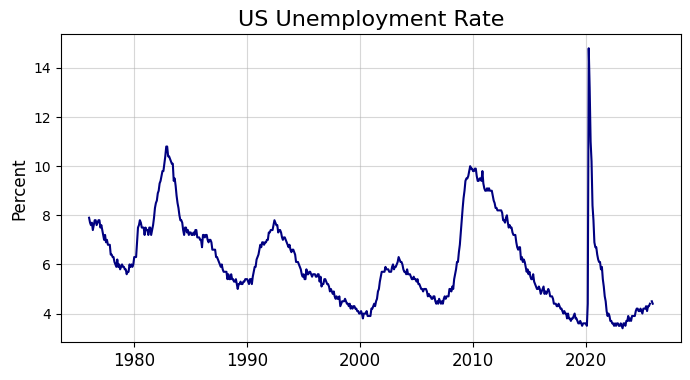

In [53]:
plt.figure(figsize=(8, 4))

# Plot with styling options
plt.plot(df.index,df["unrate"],color="navy",linewidth=1.5,linestyle="-")

# Title and axis labels with font sizes
plt.title("US Unemployment Rate", fontsize=16)

plt.ylabel("Percent", fontsize=12)

plt.xticks(fontsize=12)   # x-axis tick labels (dates)
plt.yticks(fontsize=10)   # optional: y-axis tick labels

# Add a light dashed grid
plt.grid(alpha=0.5, linestyle="-")

plt.show()

Step 3: Add shaded areas (recessions)
A great way to add context to a time-series plot is to use shaded areas. For example we can highlight recession periods.

In matplotlib you can add shaded areas with:

plt.axvspan(xmin, xmax, ...): shade a vertical region (between two points on the x-axis)
plt.axhspan(ymin, ymax, ...): shade a horizontal region (between two values on the y-axis)


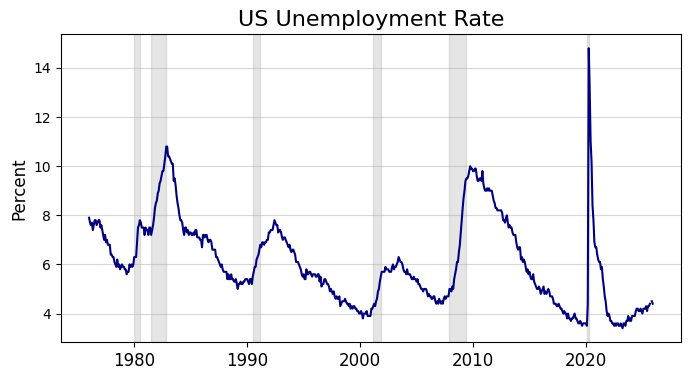

In [54]:
plt.figure(figsize=(8, 4))

# Main line
plt.plot(df.index, df["unrate"], color="navy", linewidth=1.5)

# Recession shading (examples)
plt.axvspan("1980-01-01", "1980-07-01", color="gray", alpha=0.2)
plt.axvspan("1981-07-01", "1982-11-01", color="gray", alpha=0.2)
plt.axvspan("1990-07-01", "1991-03-01", color="gray", alpha=0.2)
plt.axvspan("2001-03-01", "2001-11-01", color="gray", alpha=0.2)
plt.axvspan("2007-12-01", "2009-06-01", color="gray", alpha=0.2)
plt.axvspan("2020-02-01", "2020-04-01", color="gray", alpha=0.2)

# Labels and styling
plt.title("US Unemployment Rate", fontsize=16)
plt.ylabel("Percent", fontsize=12)
plt.xticks(fontsize=12)  
plt.grid(alpha=0.5, linestyle="-", axis="y")        # only the horizontal grid lines

plt.show()

In [55]:
recessions = [
    ("1980-01-01", "1980-07-01"),
    ("1981-07-01", "1982-11-01"),
    ("1990-07-01", "1991-03-01"),
    ("2001-03-01", "2001-11-01"),
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01"),
]

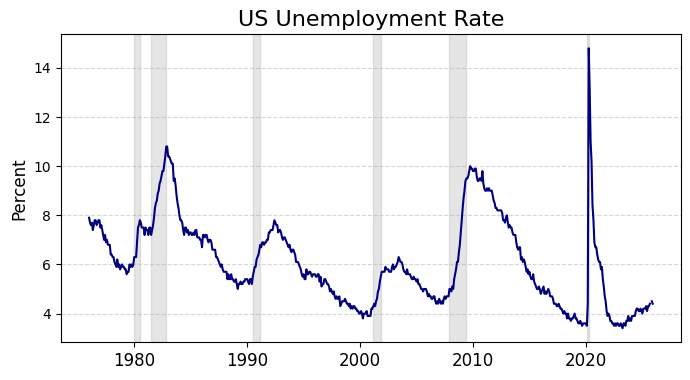

In [56]:
plt.figure(figsize=(8, 4))
plt.plot(df.index, df["unrate"], color="navy", linewidth=1.5)

# Add shaded areas for recession
for start, end in recessions:
    plt.axvspan(start, end, color="gray", alpha=0.2)

# Labels and styling
plt.title("US Unemployment Rate", fontsize=16)
plt.ylabel("Percent", fontsize=12)
plt.xticks(fontsize=12)  
plt.grid(alpha=0.5, linestyle="--", axis="y")        # only the horizontal grid lines

plt.show()

Step 4: Highlight the COVID peak with an annotation
Annotations are useful when you want to guide the reader’s attention to an important feature of a figure — for example, a turning point, an unusually high/low value, or the main takeaway from the chart. They add context directly to the visual, so the message is easier to see. You can add annotations with plt.annotate().

As an example, we will highlight the peak unemployment rate during the COVID period. Before we can annotate it, we need to prepare two pieces of information from the data:

the peak value (the highest unemployment rate in a chosen COVID window)
the date of that peak
We can do this by first selecting a time window (for example "2019-11-01":"2021-12-01"), then using:

.max() to get the highest value
.idxmax() to get the date where that maximum occurs

In [ ]:
# Prepare the data for the annotation
# 1) Select a window around the COVID period
covid_window = df.loc["2019-11-01":"2021-12-01", "unrate"]

# 2) Find the peak unemployment rate and its date
covid_peak_value = covid_window.max()            # return the highest point 
covid_peak_date = covid_window.idxmax()          # return the highest value

print(covid_peak_date)
print(covid_peak_value)

2020-04-01 00:00:00
14.8


# Basic Syntax for annotation, use this in your figure
plt.annotate(
    "Text to display",
    xy=(x_point, y_point),
    xytext=(x_text, y_text),
    arrowprops=dict(...)
)



xy=: the point we want to highlight (the COVID peak)
xytext=: where the annotation text should be placed relative to that point
arrowprops=: controls the arrow style (here an arrow pointing to the peak)
We will also use some additional arguments:

textcoords="offset points": interprets xytext as an offset in points (so (-50, -10) means move 50 left and 10 down)
ha= / va=: horizontal and vertical alignment of the text (ha=“right” and va=“bottom” help position the label neatly)
fontsize=: controls the text size
You do not need to memorize all of these annotation arguments. In practice, it is very common to start with a basic annotation and then adjust the position/style by trial and error — and this is exactly the kind of thing AI tools can help with a lot (for example, suggesting better offsets, alignment, or arrow styles).

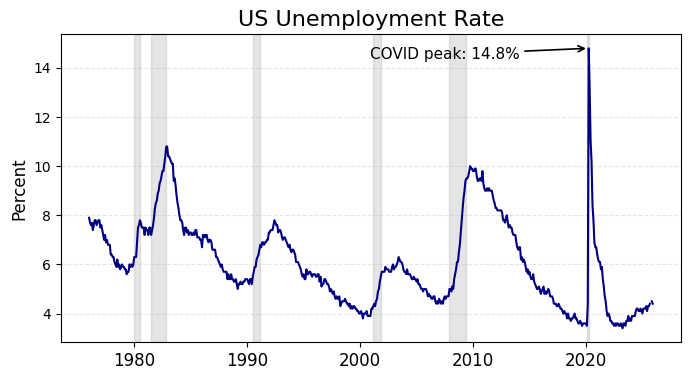

In [58]:
# 3) Create the plot
plt.figure(figsize=(8, 4))
plt.plot(df.index, df["unrate"], color="navy", linewidth=1.5)

# Add recession shading
for start, end in recessions:
    plt.axvspan(start, end, color="gray", alpha=0.2)

# Add annotation for COVID peak
plt.annotate(
    f"COVID peak: {covid_peak_value:.1f}%",
    xy=(covid_peak_date, covid_peak_value),
    xytext=(-50, -10),
    textcoords="offset points",
    ha="right",     # align text to the right edge
    va="bottom",    # align text from the bottom
    fontsize=11,
    arrowprops=dict(arrowstyle="->", color="black", lw=1.2)
)

# Labels and styling
plt.title("US Unemployment Rate", fontsize=16)
plt.ylabel("Percent", fontsize=12)
plt.xticks(fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.show()

In [59]:
# Save a high-resolution PNG to your computer
plt.savefig(
    "unemployment_covid_peak.png",
    dpi=300,                  # High resolution (300 dots per inch is standard for print)
    bbox_inches="tight"       # Ensures your axis labels and titles don't get cut off
)

plt.show()

<Figure size 640x480 with 0 Axes>

Once you have built a publication-ready chart, you will likely want to save it to include in a thesis, report, or slide deck. You can export your plot using plt.savefig().

Crucial Warning: You must call plt.savefig() before you call plt.show(). If you call it after, Matplotlib clears the canvas and will just save a blank white image!

# Save a high-resolution PNG to your computer
plt.savefig(
    "unemployment_covid_peak.png",
    dpi=300,                  # High resolution (300 dots per inch is standard for print)
    bbox_inches="tight"       # Ensures your axis labels and titles don't get cut off
)

plt.show()

(Note: You can also change the file extension to .pdf or .svg if you need a vector graphic instead of an image file.)